In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import helpers.stc_helper

ss = hf.settings_dict()

In [2]:
tmin = 1.4
tmax = 1.5
event_name = "4"
trial = 4

loading dataset for subject:  0005_3SJ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Fixing initial position: [-6.4370367024096, -69.091692566872, -6.8666381388908775] mm
Showing: t = 1.410 s, (-6.4, -69.1, -6.9) mm, [7, 4, 7] vox, 2167 vertex
Using control points [1.63410074 1.83309319 3.0015416 ]


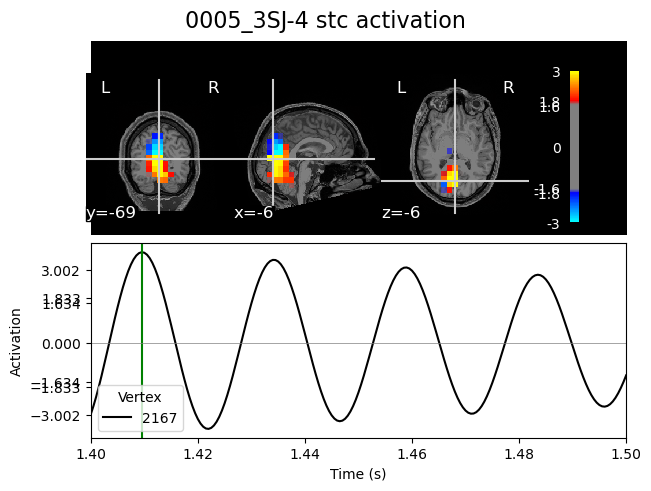

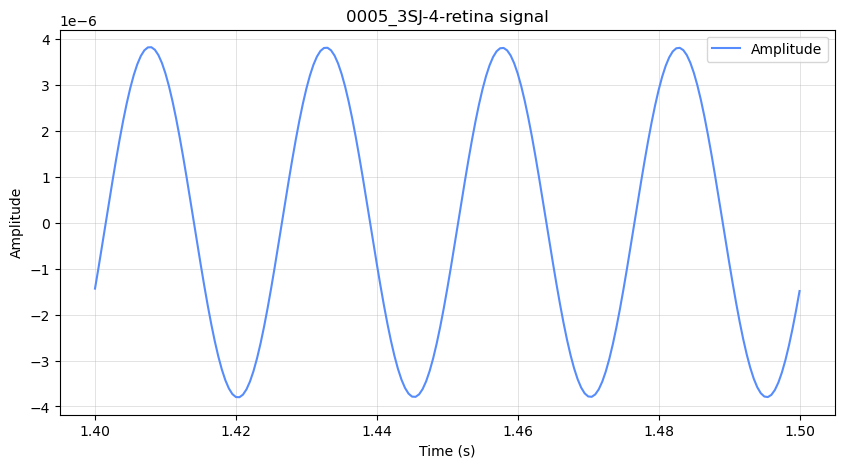

Fixing initial position: [-6.4370367024096, -69.091692566872, -6.8666381388908775] mm
Showing: t = 1.401 s, (-6.4, -69.1, -6.9) mm, [7, 4, 7] vox, 2167 vertex
Using control points [3.02947159 3.07399758 3.14098604]


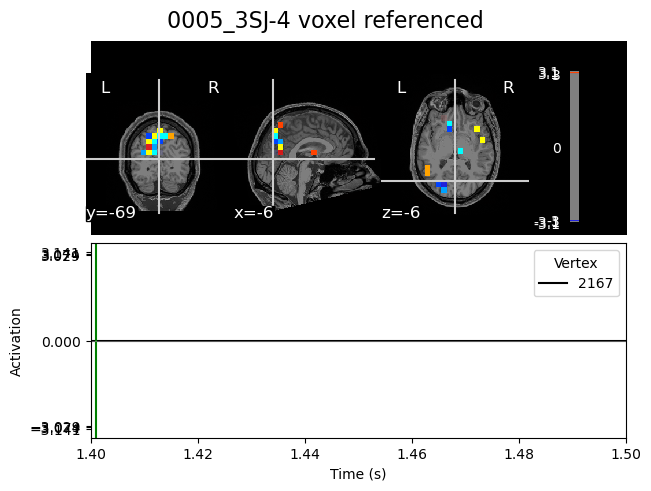

Fixing initial position: [-6.4370367024096, -69.091692566872, -6.8666381388908775] mm
Showing: t = 1.400 s, (-6.4, -69.1, -6.9) mm, [7, 4, 7] vox, 2167 vertex
Using control points [3.00274678 3.05466588 3.13965308]


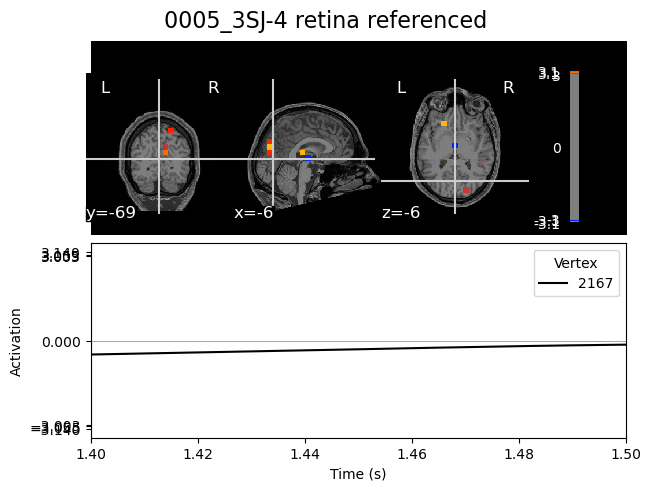

loading dataset for subject:  0002_TCZ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Fixing initial position: [29.09992914646864, -69.99994458257974, 39.64848384261167] mm
Showing: t = 1.443 s, (29.1, -70.0, 39.6) mm, [11, 3, 10] vox, 3845 vertex
Using control points [1.14993673 1.26580842 2.27868123]


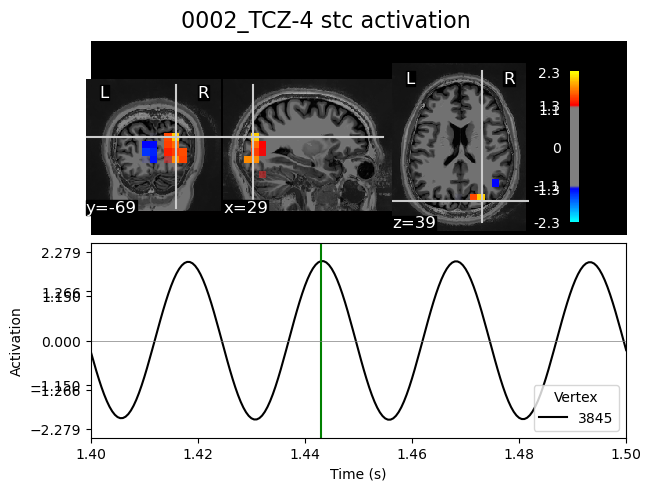

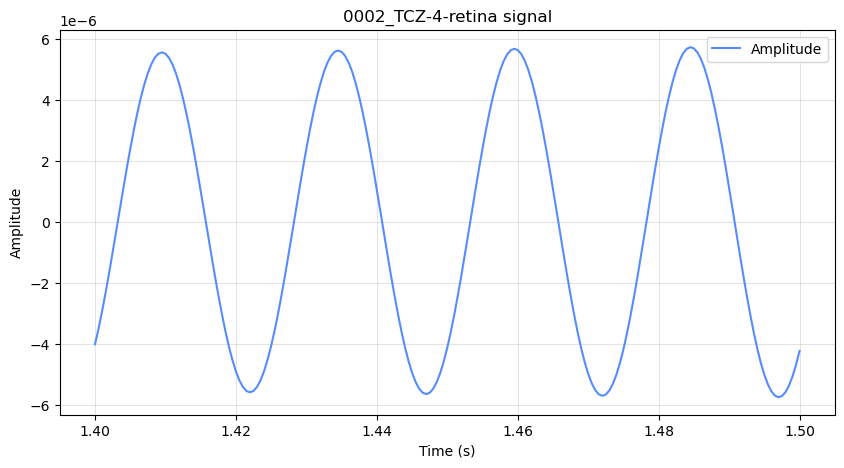

Fixing initial position: [29.09992914646864, -69.99994458257974, 39.64848384261167] mm
Showing: t = 1.402 s, (29.1, -70.0, 39.6) mm, [11, 3, 10] vox, 3845 vertex
Using control points [2.97209538 3.03516152 3.13947229]


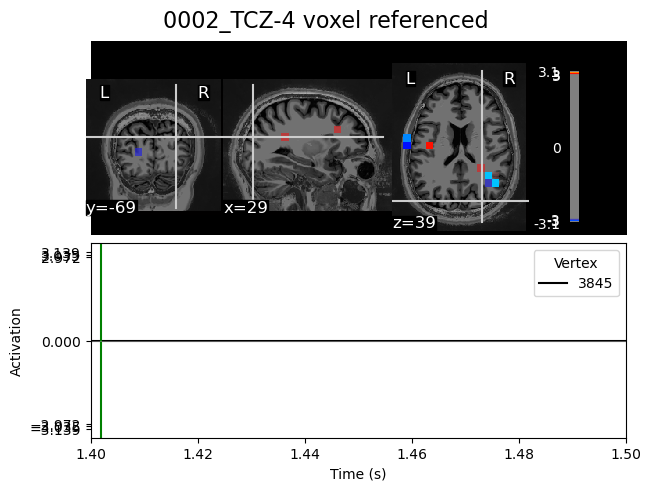

Fixing initial position: [29.09992914646864, -69.99994458257974, 39.64848384261167] mm
Showing: t = 1.451 s, (29.1, -70.0, 39.6) mm, [11, 3, 10] vox, 3845 vertex
Using control points [2.95044948 3.02060318 3.13898016]


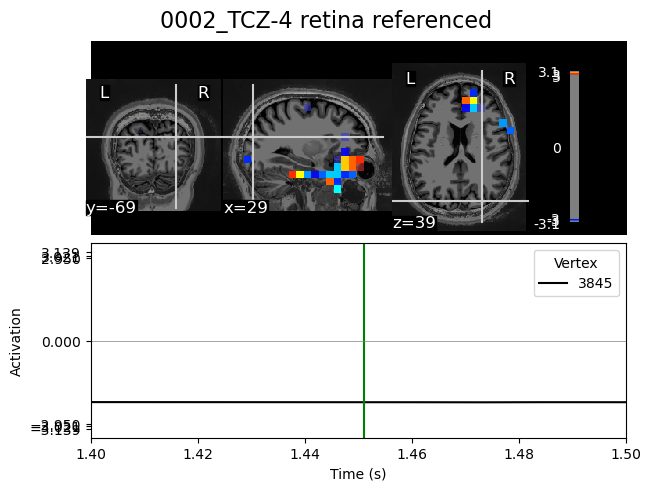

loading dataset for subject:  0009_YGZ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1225 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Fixing initial position: [-12.8881244454533, -75.30076783150433, -5.544021762907512] mm
Showing: t = 1.461 s, (-12.9, -75.3, -5.5) mm, [6, 2, 4] vox, 1176 vertex
Using control points [1.58129948 1.74129093 3.4009167 ]


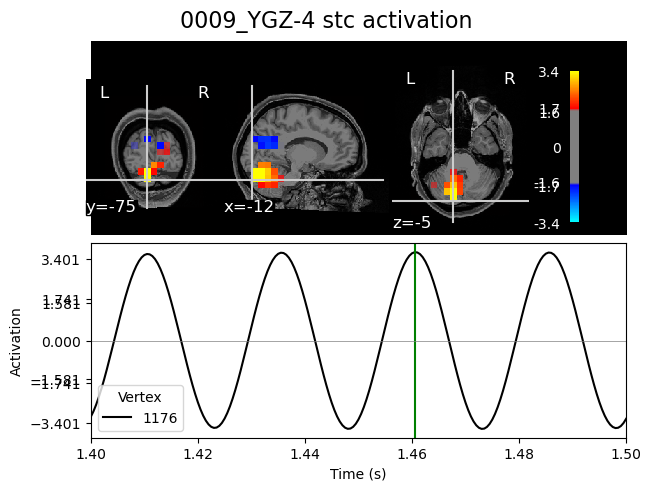

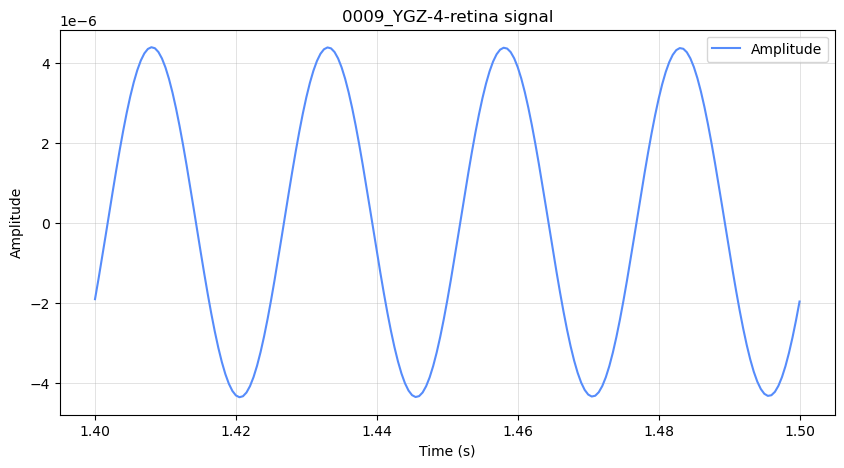

Fixing initial position: [-12.8881244454533, -75.30076783150433, -5.544021762907512] mm
Showing: t = 1.400 s, (-12.9, -75.3, -5.5) mm, [6, 2, 4] vox, 1176 vertex
Using control points [3.05914029 3.08826461 3.14059258]


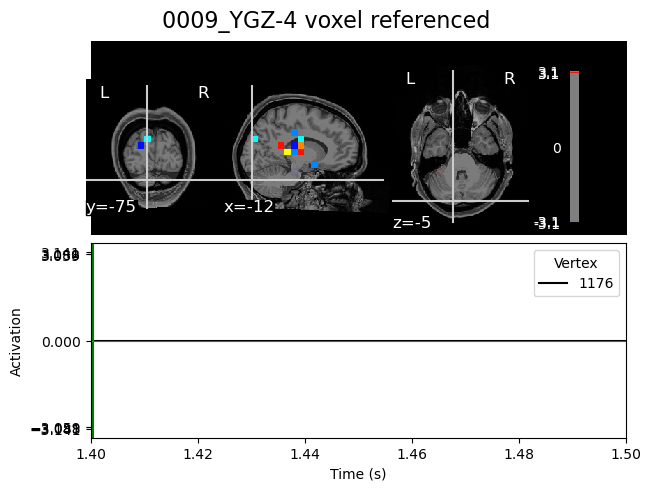

Fixing initial position: [-12.8881244454533, -75.30076783150433, -5.544021762907512] mm
Showing: t = 1.447 s, (-12.9, -75.3, -5.5) mm, [6, 2, 4] vox, 1176 vertex
Using control points [2.95183266 3.02024331 3.13908282]


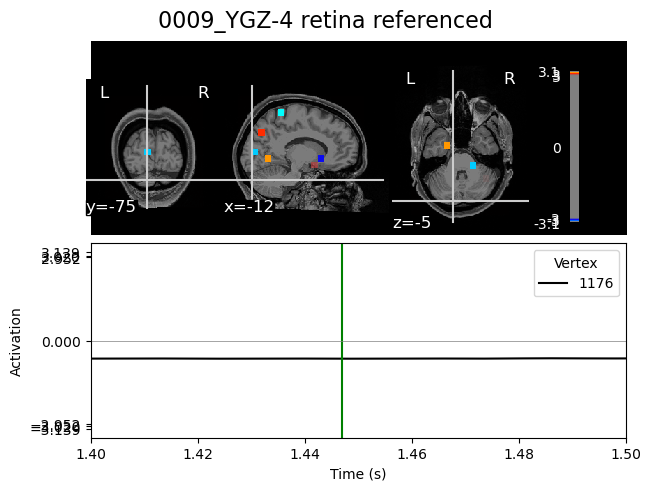

loading dataset for subject:  0010_ZMG
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0010_ZMG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Fixing initial position: [-14.366075431462377, -81.31019912194459, -5.5626193061470985] mm
Showing: t = 1.407 s, (-14.4, -81.3, -5.6) mm, [6, 2, 7] vox, 2136 vertex
Using control points [1.56334381 1.71233465 2.87992542]


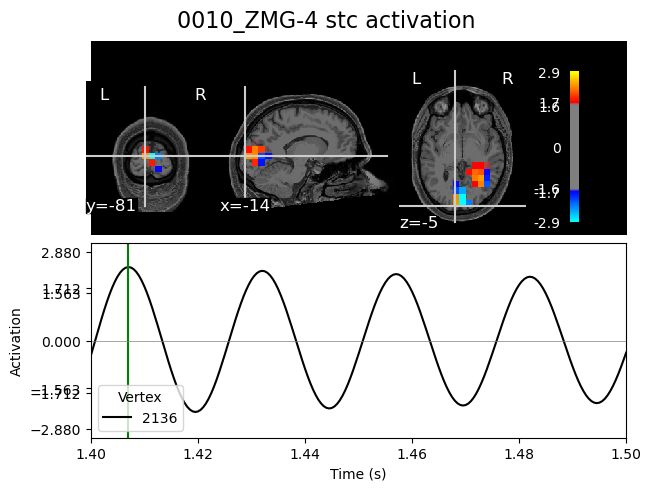

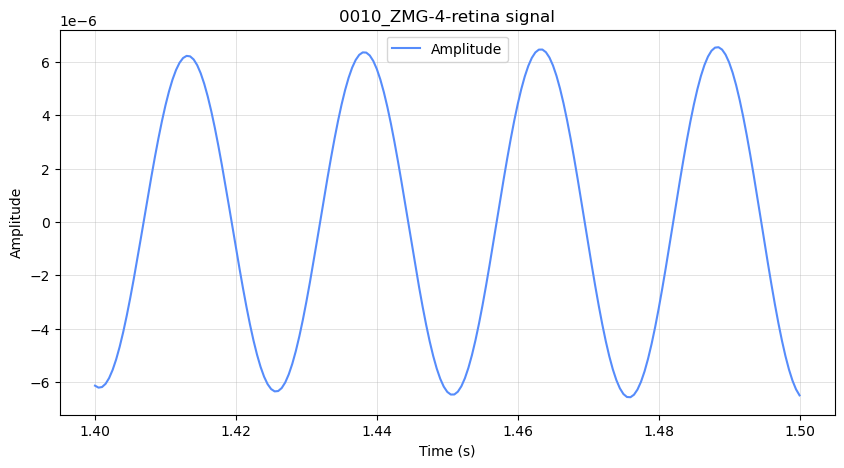

Fixing initial position: [-14.366075431462377, -81.31019912194459, -5.5626193061470985] mm
Showing: t = 1.416 s, (-14.4, -81.3, -5.6) mm, [6, 2, 7] vox, 2136 vertex
Using control points [2.9913836  3.04868826 3.13965448]


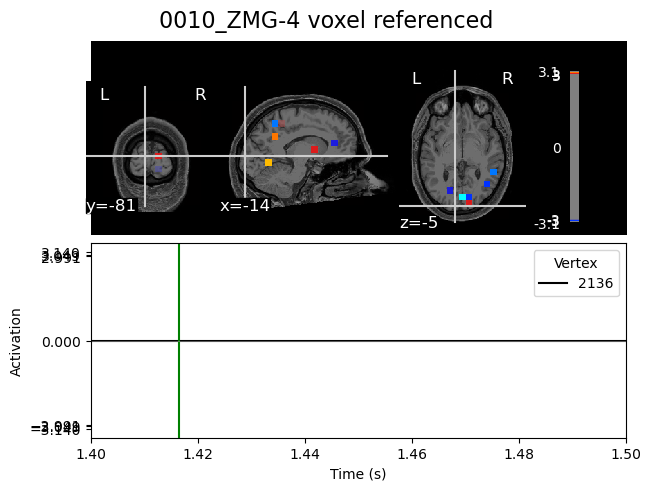

Fixing initial position: [-14.366075431462377, -81.31019912194459, -5.5626193061470985] mm
Showing: t = 1.500 s, (-14.4, -81.3, -5.6) mm, [6, 2, 7] vox, 2136 vertex
Using control points [3.02631945 3.06488459 3.13991883]


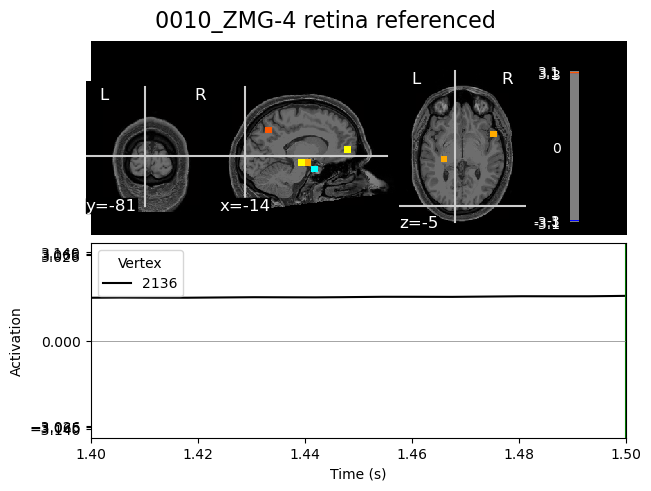

In [3]:
from helpers import stc_helper


for subject_index in ss['subject_idx_list']:
    subjects_dir = ss['fs_subjects_dir']
    subject = ss['subject_id_list'][subject_index]
    print("loading dataset for subject: ", subject)

    stc_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-{trial}-vol.stc"

    stc = mne.read_source_estimate(stc_file)
    stc.crop(tmin=tmin, tmax=tmax)

    fwd_fname = op.join(ss['fwd_dir'], subject + '-fwd.fif')
    fwd = mne.read_forward_solution(fwd_fname)
    src = fwd['src']

    if src[0]['subject_his_id'].startswith("fs"):
        src[0]['subject_his_id'] = subject

    reference_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-event-{event_name}-reference.csv"

    # Read the CSV file
    df = pd.read_csv(reference_file)
    # get voxel number
    voxel = int(df.axes[1][2].split("_")[0])

    coords = stc_helper.extract_voxel_coords_from_stc(stc=stc, voxel=voxel, src=src)

    coords = divided = [num / 1000 for num in coords]

    brain = mne.viz.plot_volume_source_estimates(
        stc,
        subject=subject,
        subjects_dir=subjects_dir,
        src=src,
        initial_pos = coords,
        show=False,)

    # Add a title to the figure
    brain.suptitle(f"{subject}-{event_name} stc activation", fontsize=16)

    # Display the plot
    plt.show()

    # Plot the retina signal over time

    retina_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-retina.csv"

    # Read the CSV file
    df = pd.read_csv(retina_file)

    #crop dataframe
    df_cropped = df[(df['time_s'] >= tmin) & (df['time_s'] <= tmax)]

    # Plot amplitude over time
    plt.figure(figsize=(10, 5))
    plt.plot(df_cropped["time_s"], df_cropped["amplitude"], label="Amplitude")

    # Labels and title
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{subject}-{event_name}-retina signal")
    plt.grid(True)
    plt.legend()

    # Show the plot
    plt.show()

        # load hilbert stc data
    phase_diff_voxel_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-hilbert-vox-ref-vol.stc"
    phase_diff_voxel_stc = mne.read_source_estimate(phase_diff_voxel_stc_file)
    phase_diff_voxel_stc.crop(tmin=tmin, tmax=tmax)

    phase_diff_retina_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-hilbert-ret-ref-vol.stc"
    phase_diff_retina_stc = mne.read_source_estimate(phase_diff_retina_stc_file)
    phase_diff_retina_stc.crop(tmin=tmin, tmax=tmax)

    brain = mne.viz.plot_volume_source_estimates(
        phase_diff_voxel_stc,
        subject=subject,
        subjects_dir=subjects_dir,
        src=src,
        initial_pos = coords,
        show=False,)

    # Add a title to the figure
    brain.suptitle(f"{subject}-{event_name} voxel referenced", fontsize=16)

    # Display the plot
    plt.show()

    brain = mne.viz.plot_volume_source_estimates(
        phase_diff_retina_stc,
        subject=subject,
        subjects_dir=subjects_dir,
        src=src,
        initial_pos = coords,
        show=False,)

        # Add a title to the figure
    brain.suptitle(f"{subject}-{event_name} retina referenced", fontsize=16)

    # Display the plot
    plt.show()

    del stc
